# An implementation of Multi-Task Learning using convolutional neural networks.

## Introduction:
Multi-Task Learning is a machine learning technique where you try to use one large model to predict 2 different outputs where the feature space is very similar.  This allows the model to "Share Information" within one another so that instead of having 2 independent predictions.  You create 2 predcitions that learn from eachother.

In this case study, we want to predict 2 different values: a categorical value **classifying* the time frame that a customer will purchase a ticket, as well as an explicitely prediction of how many days in advance the customer will purchase a ticket. 

In [155]:
import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader 
import dotenv as de

import numpy as np
import pandas as pd 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, r2_score, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Class 1: Dataset Prep
A key step in dataset prep is to properly convert all of the columns into torch tensors for preparation for the archetecture. The constructor acomplishes the following tasks
- Rescale numeric columns using standard scaler
- Encode categorical columns using LabelEncoder()
- convert label vectors to torch tensors. 

In [156]:
class TicketDataset(Dataset):
    def __init__(
        self, df, numeric_cols, categorical_cols,
        reg_target, clf_target, scalar=None,
        encoders=None, clf_encoder=None, fit=True
    ):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols

        num_data = df[numeric_cols].to_numpy(dtype=np.float32)

        if fit:
            self.scalar = StandardScaler()
            num_data = self.scalar.fit_transform(num_data)
        else:
            self.scalar = scalar
            num_data = self.scalar.transform(num_data)

        self.num_data = torch.tensor(num_data, dtype=torch.float32)

        self.encoders = encoders if encoders is not None else {}
        cat_encoded = []

        for col in categorical_cols:
            if fit:
                encoder = LabelEncoder()
                encoded = encoder.fit_transform(df[col].astype(str))
                self.encoders[col] = encoder
            else:
                encoder = self.encoders[col]
                encoded = df[col].astype(str).map(
                    lambda value: (
                        encoder.transform([value])[0]
                        if value in encoder.classes_ else 0
                    )
                ).to_numpy()

            cat_encoded.append(encoded)

        # --- FIX: guard the empty case ---
        if categorical_cols:
            self.cat_data = torch.tensor(
                np.stack(cat_encoded, axis=1), dtype=torch.long
            )
        else:
            self.cat_data = torch.empty((len(df), 0), dtype=torch.long)

        if fit:
            self.clf_encoder = LabelEncoder()
            clf_encoded = self.clf_encoder.fit_transform(
                df[clf_target].astype(str)
            )
        else:
            self.clf_encoder = clf_encoder
            clf_encoded = self.clf_encoder.transform(
                df[clf_target].astype(str)
            )

        self.reg_y = torch.tensor(
            df[reg_target].to_numpy(dtype=np.float32)
        )
        self.clf_y = torch.tensor(clf_encoded, dtype=torch.long)

    def __len__(self):
        return len(self.reg_y)

    def __getitem__(self, index):
        return (
            self.num_data[index],
            self.cat_data[index],
            self.reg_y[index],
            self.clf_y[index],
        )

## Class 2 & 3: Multi-Task Network & Uncertainty Weight
The key hurdle that Multi-Task Learning faces compared to traditional modeling approaches is that we require a unified loss function that encompases both regression and classfication.  I.e. our "loss function" will be a weighted average between the 2 
$$
    Loss = \omega_1 * (Regression Loss) + \omega_2 * (Classification Loss)
$$
Each sub problem will have loss function
- Regression Loss -> Mean Squared Error
- Classification Loss -> Categorical Cross Entropy

During training these weights will dynamically update.

In [157]:
class MultiTaskNet(nn.Module):
    def __init__(
            self,
            num_numeric,
            cat_cardinalities,
            n_classes=3,
            trunk_dims=(64,32),
            emb_dropout=0.1,
            trunk_dropout=0.2
    ):

        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(card, min(50, (card + 1) // 2))
            for card in cat_cardinalities 
        ])
        emb_total = sum(min(50, (c + 1) // 2) for c in cat_cardinalities)
        self.emb_dropout = nn.Dropout(emb_dropout)

        input_dim = num_numeric + emb_total 

        trunk_layers = []
        prev = input_dim
        for dim in trunk_dims:
            trunk_layers += [
                nn.Linear(prev, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(trunk_dropout)
            ]
            prev=dim 

        self.trunk = nn.Sequential(*trunk_layers)
        trunk_out = prev

        # --- Task Heads --- 
        self.reg_head = nn.Sequential(
            nn.Linear(trunk_out, trunk_out // 2), nn.ReLU(),
            nn.Linear(trunk_out // 2, 1) 
        )
        self.clf_head = nn.Sequential(
            nn.Linear(trunk_out, trunk_out // 2), nn.ReLU(),
            nn.Linear(trunk_out // 2, n_classes)
        )

    def forward(self, x_num, x_cat):
        if len(self.embeddings) > 0:
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            x_cat_emb = self.emb_dropout(torch.cat(embs, dim=1))
            x = torch.cat([x_num, x_cat_emb], dim = 1)
        else:
            x = x_num 

        shared = self.trunk(x)
        reg_out = self.reg_head(shared).squeeze(-1)
        clf_logits = self.clf_head(shared)
        return reg_out, clf_logits


class UncertaintyWeightedLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.log_var_reg = nn.Parameter(torch.zeros(1))
        self.log_var_clf = nn.Parameter(torch.zeros(1))

    def forward(self, reg_pred, reg_true, clf_logits, clf_true):
        reg_loss = F.smooth_l1_loss(reg_pred, reg_true)
        clf_loss = F.cross_entropy(clf_logits, clf_true)

        loss = (
            torch.exp(-self.log_var_reg) * reg_loss + self.log_var_reg
            + torch.exp(-self.log_var_clf) * clf_loss + self.log_var_clf
        )
        return loss.squeeze(), reg_loss.item(), clf_loss.item()

In [158]:
def train(model, loss_fn, train_loader, val_loader, epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(loss_fn.parameters()), lr=lr
    )

    device = 'cuda' if torch.cuda.is_available() else 'cpu' 
    model.to(device); loss_fn.to(device)

    for epoch in range(epochs):
        model.train()
        for x_num, x_cat, reg_y, clf_y in train_loader:
            x_num, x_cat = x_num.to(device), x_cat.to(device)
            reg_y, clf_y = reg_y.to(device), clf_y.to(device)

            optimizer.zero_grad()
            reg_pred, clf_logits = model(x_num, x_cat)
            loss, r_loss, c_loss = loss_fn(reg_pred, reg_y, clf_logits, clf_y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_mae, val_acc, n = 0, 0, 0
        with torch.no_grad():
            for x_num, x_cat, reg_y, clf_y in val_loader:
                x_num, x_cat = x_num.to(device), x_cat.to(device)
                reg_y, clf_y = reg_y.to(device), clf_y.to(device)
                reg_pred, clf_logits = model(x_num, x_cat)
                val_mae += (reg_pred - reg_y).abs().sum().item()
                val_acc += (clf_logits.argmax(1) == clf_y).sum().item()
                n += len(reg_y)
        print(f"Epoch {epoch+1:3d} | reg_loss {r_loss:.3f} "
              f"clf_loss {c_loss:.3f} | val log-MAE {val_mae/n:.3f} "
              f"val Acc {val_acc/n:.3f}")

## Build Dataset

In [159]:
DATASET_NAME = de.get_key(".env", "DATASET_NAME")

data = pd.read_excel(f"data/{DATASET_NAME}", sheet_name = [1,2]) #Load in the 2nd and 3rd sheets of the excel file (all other sheets contain metadata and are not relevant)
DATA_ORIGINAL = pd.concat([data[1], data[2]], axis=0, ignore_index=True)
def preprocess_dataframe(df_orig):
    df = df_orig.copy() #Copy the original dataset

    df['Fan_Mailing_List'] = df['Fan_Mailing_List'].map({"Yes" : 1, "No" : 0}).astype(bool)
    df['Seat_Is_Upper'] = df['Seat_Location'].map({"Upper" : 1, "Lower" : 0}).astype(bool)

    df['Days_Before_Game'] = df['Days_Before_Game'].astype("float64")

    return df 

DATA = preprocess_dataframe(DATA_ORIGINAL)

In [160]:
numeric_cols = ['Num_Tickets_Purchased', 'Age', 'Ticket_Price', 'Seat_Is_Upper', 'Fan_Mailing_List']
categorical_cols = []
reg_label='Days_Before_Game'
clf_label = 'Customer_Type'

train_df, temp_df = train_test_split(
    DATA, test_size=0.3, random_state=42,
    stratify=DATA[clf_label]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df[clf_label]
)

train_ds = TicketDataset(train_df, numeric_cols, categorical_cols, reg_label, clf_label,  fit=True)
val_ds = TicketDataset(
    val_df, numeric_cols, categorical_cols, 
    reg_label, clf_label, 
    scalar=train_ds.scalar,
    encoders=train_ds.encoders,
    clf_encoder=train_ds.clf_encoder,
    fit=False
)

test_ds = TicketDataset(
    test_df, numeric_cols, categorical_cols, 
    reg_label, clf_label, 
    scalar=train_ds.scalar,
    encoders=train_ds.encoders,
    clf_encoder=train_ds.clf_encoder,
    fit=False
)

cat_cards = [train_df[c].nunique() for c in categorical_cols]

model = MultiTaskNet(num_numeric=len(numeric_cols), cat_cardinalities=cat_cards, n_classes=3)

loss_fn = UncertaintyWeightedLoss()

train(model, loss_fn,
    DataLoader(train_ds, batch_size=64, shuffle=True),
    DataLoader(val_ds, batch_size=256),
    epochs=50
)

Epoch   1 | reg_loss 10.298 clf_loss 1.027 | val log-MAE 11.102 val Acc 0.477
Epoch   2 | reg_loss 12.359 clf_loss 0.973 | val log-MAE 10.975 val Acc 0.550
Epoch   3 | reg_loss 8.916 clf_loss 0.915 | val log-MAE 10.781 val Acc 0.689
Epoch   4 | reg_loss 9.754 clf_loss 0.799 | val log-MAE 10.512 val Acc 0.709
Epoch   5 | reg_loss 10.638 clf_loss 0.733 | val log-MAE 10.188 val Acc 0.689
Epoch   6 | reg_loss 7.905 clf_loss 0.714 | val log-MAE 9.772 val Acc 0.675
Epoch   7 | reg_loss 8.026 clf_loss 0.666 | val log-MAE 9.291 val Acc 0.702
Epoch   8 | reg_loss 9.189 clf_loss 0.623 | val log-MAE 8.726 val Acc 0.695
Epoch   9 | reg_loss 9.154 clf_loss 0.697 | val log-MAE 8.114 val Acc 0.689
Epoch  10 | reg_loss 7.616 clf_loss 0.655 | val log-MAE 7.391 val Acc 0.689
Epoch  11 | reg_loss 7.084 clf_loss 0.608 | val log-MAE 6.549 val Acc 0.689
Epoch  12 | reg_loss 7.033 clf_loss 0.583 | val log-MAE 5.966 val Acc 0.715
Epoch  13 | reg_loss 4.867 clf_loss 0.599 | val log-MAE 5.575 val Acc 0.715
Epoc

## Evaluate the model on the test set.

In [161]:
@torch.no_grad()
def collect_predictions(model, loader, device, multitask=True):
    model.eval()
    reg_preds, reg_trues, clf_preds, clf_trues = [], [], [], []
    for x_num, x_cat, reg_y, clf_y in loader:
        x_num, x_cat = x_num.to(device), x_cat.to(device)
        reg_out, clf_logits = model(x_num, x_cat)
        reg_preds.append(reg_out.cpu().numpy())
        clf_preds.append(clf_logits.argmax(1).cpu().numpy())
        reg_trues.append(reg_y.numpy())
        clf_trues.append(clf_y.numpy())

    reg_pred = np.concatenate(reg_preds)
    reg_true = np.concatenate(reg_trues)


    return (reg_pred, reg_true,
            np.concatenate(clf_preds), np.concatenate(clf_trues))

def report_metrics(reg_pred, reg_true, clf_pred, clf_true, label=""):
    mae = mean_absolute_error(reg_true, reg_pred)
    r2 = r2_score(reg_true, reg_pred)
    rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))

    acc = accuracy_score(clf_true, clf_pred)
    f1 = f1_score(clf_true, clf_pred, average='macro')

    print(f"===== {label} =====")
    print(f"  Regression   | MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")
    print(f"  Classification   | Acc: {acc:.3f}  Macro-F1: {f1:.3f}")
    return {'mae' : mae, 'rmse' : rmse, 'R2' : r2, 'acc' : acc, 'f1' : f1}

### Train Single model approaches

In [162]:
X_train = train_df[numeric_cols + categorical_cols]
y_reg_train = train_df[reg_label]
y_clf_train = train_df[clf_label]

X_test = test_df[numeric_cols + categorical_cols]
y_reg_test = test_df[reg_label]
y_clf_test = test_df[clf_label]

# ---------- Regression Model ------------
regression_model = RandomForestRegressor()
regression_model.fit(X_train, y_reg_train)
reg_pred = regression_model.predict(X_test)

# ---------- Classification Model --------
classification_model = RandomForestClassifier()
classification_model.fit(X_train, y_clf_train)
clf_pred = classification_model.predict(X_test)


### Collect Multi-Task Model Predictions

In [163]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
test_loader = DataLoader(test_ds, batch_size=256)

r_pred, r_true, c_pred, c_true = collect_predictions(model, test_loader, device)

mtl_scores = report_metrics(r_pred, r_true, c_pred, c_true, "Multi-Task")

stl_scores = report_metrics(reg_pred, y_reg_test, clf_pred, y_clf_test, "Single-Model-Learning")


===== Multi-Task =====
  Regression   | MAE: 4.162  RMSE: 6.070  R2: 0.633
  Classification   | Acc: 0.795  Macro-F1: 0.795
===== Single-Model-Learning =====
  Regression   | MAE: 4.614  RMSE: 6.227  R2: 0.614
  Classification   | Acc: 0.728  Macro-F1: 0.732


In [164]:
print("reg log_var:", loss_fn.log_var_reg.item())
print("clf log_var:", loss_fn.log_var_clf.item())

reg log_var: 0.3095317482948303
clf log_var: -0.4978407621383667


## Further Diagnostics

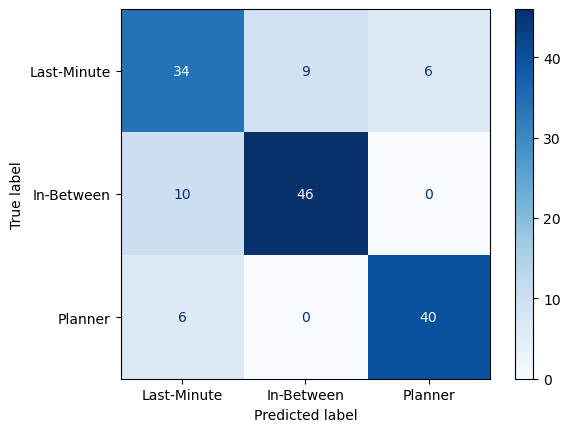

In [165]:
confusion_mat = confusion_matrix(c_true, c_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=list(DATA[clf_label].unique()))
disp.plot(cmap=plt.cm.Blues)

### Regression Analysis

Text(0, 0.5, 'Residual')

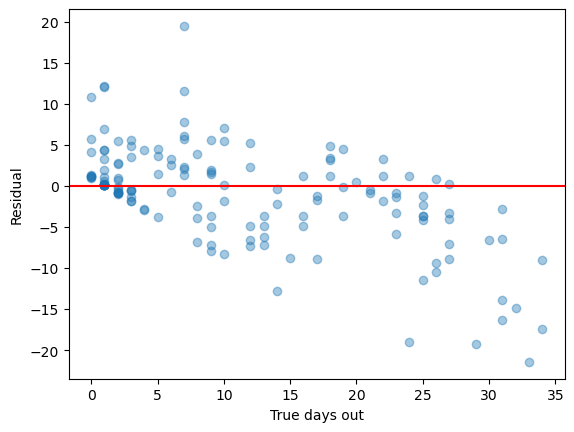

In [166]:
plt.scatter(r_true, r_pred - r_true, alpha=0.4)
plt.axhline(0, color='r')
plt.xlabel('True days out')
plt.ylabel('Residual')

Initial model reports sytematic bias that will try to account for by log-transforming into the dataset.